In [1]:
from MyPlotRecipe.SharedX import ShareXaxis
from MyPlotRecipe.UniversalColor import UniversalColor
from MyPlotRecipe.legend_shadow import legend_shadow
import numpy as np
import math

from scipy import signal
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick
from matplotlib.ticker import FixedLocator

import spiceypy as spice

from CSField import CSField
import JupiterMag as jm

jm.Internal.Config(Model='jrm33', CartesianIn=True,
                   CartesianOut=True)
jm.Con2020.Config(equation_type='integral')

UC = UniversalColor()
UC.set_palette()

spice.furnsh(
    '/Users/shin/Documents/Research/Jupiter/Codes/HST/kernel/cassMetaK.txt')

Importing Library
done


In [2]:
def day2hhmm(decimal_day):
    doy = int(decimal_day)
    rest = decimal_day - doy

    hours = int(rest*24)
    minutes = (rest*24-hours)*60

    if round(minutes) >= 60:
        hours += 1
        minutes = 0
    else:
        minutes = round(minutes)
    return hours, minutes


def hhmm2day(hours, minutes, seconds=0):
    fraction_of_day = hours/24 + minutes/(60*24) + seconds/(60*60*24)
    return fraction_of_day


def fmt_hhmm(decimal_day):
    hours, minutes = day2hhmm(decimal_day)
    hh = '{:02}'.format(hours)
    mm = '{:02}'.format(minutes)
    return hh+':'+mm

In [3]:
# 定数
RJ = 71492*1E+3  # Jupiter radius [m]
RE = 1560*1E+3   # Europa radius [m]
# Angular velocity of Jupiter System III rotation [rad sec-1]
OMG_J = 2*np.pi/(9.55*3600)
OMG_G = 2*np.pi/(7.2*24*3600)   # Ganymede orbital angular velosity [rad/sec]

Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

In [4]:
PJ_num = 7

Bx, By, Bz = np.zeros(3), np.zeros(3), np.zeros(3)
time = np.zeros(3)
rx, ry, rz = np.zeros(3), np.zeros(3), np.zeros(3)
utc = []

filename = [
    'data/raw/fgm_jno_l3_2017190pc_r60s_v01.sts',
    'data/raw/fgm_jno_l3_2017191pc_pj07_r60s_v02.sts',
    'data/raw/fgm_jno_l3_2017191pc_r60s_v02.sts',
    'data/raw/fgm_jno_l3_2017192pc_r60s_v02.sts',
    'data/raw/fgm_jno_l3_2017193pc_r60s_v01.sts',
]

dir = '/Users/shin/Documents/Research/Juno/Mag/Codes/'
for i in range(len(filename)):
    f = np.loadtxt(dir+'/'+filename[i], skiprows=125)
    Bx = np.append(Bx, f[:, 7])
    By = np.append(By, f[:, 8])
    Bz = np.append(Bz, f[:, 9])
    time = np.append(time, f[:, 6])  # [day]
    rx = np.append(rx, f[:, 11])     # [km]
    ry = np.append(ry, f[:, 12])     # [km]
    rz = np.append(rz, f[:, 13])     # [km]
    for j in range(f[:, 0].size):
        utc += [str(int(f[j, 0]))+'-'+str(int(f[j, 1]))+'T'+str(int(f[j, 2])
                                                                ).zfill(2)+':'+str(int(f[j, 3])).zfill(2)+':'+str(int(f[j, 4])).zfill(2)]

Bx, By, Bz = Bx[3:], By[3:], Bz[3:]
time = time[3:]
rx, ry, rz = rx[3:], ry[3:], rz[3:]

time_argsort = np.argsort(time)
Bx, By, Bz = Bx[time_argsort], By[time_argsort], Bz[time_argsort]
rx, ry, rz = rx[time_argsort], ry[time_argsort], rz[time_argsort]
time = time[time_argsort]
print(time[0], fmt_hhmm(time[0]))
print(time[-1], fmt_hhmm(time[-1]))
print(utc)
print(len(utc), time.size)
print('r_start: ', np.sqrt(rx[0]**2+ry[0]**2+rz[0]**2)/71492.0)
print('r_end:', np.sqrt(rx[-1]**2+ry[-1]**2+rz[-1]**2)/71492.0)

190.007998189 00:12
193.999664196 24:00
['2017-190T00:11:31', '2017-190T00:12:31', '2017-190T00:13:31', '2017-190T00:14:31', '2017-190T00:15:31', '2017-190T00:16:31', '2017-190T00:17:31', '2017-190T00:18:31', '2017-190T00:19:31', '2017-190T00:20:31', '2017-190T00:21:31', '2017-190T00:22:31', '2017-190T00:23:31', '2017-190T00:24:31', '2017-190T00:25:31', '2017-190T00:26:31', '2017-190T00:27:31', '2017-190T00:28:31', '2017-190T00:29:31', '2017-190T00:30:31', '2017-190T00:31:31', '2017-190T00:32:31', '2017-190T00:33:31', '2017-190T00:34:31', '2017-190T00:35:31', '2017-190T00:36:31', '2017-190T00:37:31', '2017-190T00:38:31', '2017-190T00:39:31', '2017-190T00:40:31', '2017-190T00:41:31', '2017-190T00:42:31', '2017-190T00:43:31', '2017-190T00:44:31', '2017-190T00:45:31', '2017-190T00:46:31', '2017-190T00:47:31', '2017-190T00:48:31', '2017-190T00:49:31', '2017-190T00:50:31', '2017-190T00:51:31', '2017-190T00:52:31', '2017-190T00:53:31', '2017-190T00:54:31', '2017-190T00:55:31', '2017-190T00:5

In [5]:
# Juno探査機のMLTを計算
MLT = np.zeros(len(utc))
for j in range(len(utc)):
    # Jupiterから見たJunoの位置
    r_juno, _ = spice.spkpos(
        "JUNO",
        spice.utc2et(utc[j]),
        "IAU_JUPITER",
        "NONE",
        "JUPITER"
    )

    R = spice.pxform(
        "IAU_JUPITER",
        "JUNO_JSO",
        spice.utc2et(utc[j])
    )
    r_jso = R @ r_juno

    x_jso, y_jso, z_jso = r_jso
    phi = np.arctan2(y_jso, x_jso)
    phi = np.mod(phi, 2*np.pi)
    MLT[j] = (12.0 + phi / (2*np.pi) * 24.0) % 24.0

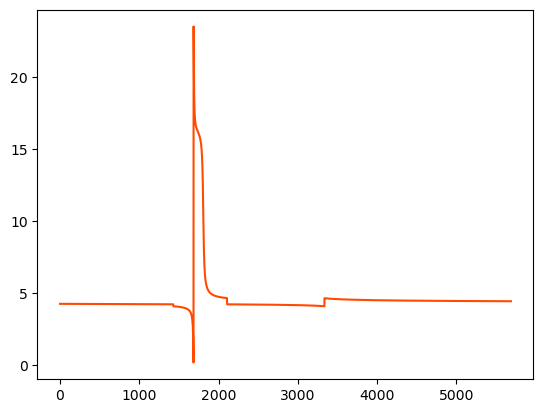

In [6]:
plt.plot(MLT)

In [7]:
print(1/((time[2]-time[1])*60*60*24),  'Hz')

0.016666653333500165 Hz


In [8]:
f_resample = (1/(60*2))       # [Hz]
T_resample = 1/f_resample   # [sec]
t0 = time[1]        # obs. start time [sec]
t1 = time[-1]       # obs. end time [sec]

print(t0, t1)
print(t0+T_resample)

190.008692633 193.999664196
310.008692633


In [9]:
# 新しい時間軸
time_arr = np.arange(t0, t1, T_resample/(60*60*24))
print(time_arr.shape)
print(time_arr[0])

(2874,)
190.008692633


In [10]:
# リサンプル
Bx_re = np.zeros(time_arr.shape)
By_re = np.zeros(time_arr.shape)
Bz_re = np.zeros(time_arr.shape)
rx_re = np.zeros(time_arr.shape)
ry_re = np.zeros(time_arr.shape)
rz_re = np.zeros(time_arr.shape)
time_sec = time*60*60*24                # 元データの時間軸
time_arr_sec = time_arr*60*60*24        # 新しい時間軸

# np.interpを使ってリサンプリングしてみる (線形補間)
Bx_re = np.interp(time_arr_sec, time_sec, Bx)
By_re = np.interp(time_arr_sec, time_sec, By)
Bz_re = np.interp(time_arr_sec, time_sec, Bz)
rx_re = np.interp(time_arr_sec, time_sec, rx)
ry_re = np.interp(time_arr_sec, time_sec, ry)
rz_re = np.interp(time_arr_sec, time_sec, rz)

In [11]:
savedir = 'data/FGM/PJ'+str(int(PJ_num)).zfill(2)+'/'
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_Bx.txt', Bx_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_By.txt', By_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_Bz.txt', Bz_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_rx.txt', rx_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_ry.txt', ry_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_rz.txt', rz_re)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_time.txt', time_arr)
np.savetxt(
    savedir+'fgm_PJ'+str(int(PJ_num)).zfill(2)+'_pc_2min_JunoMLT.txt', MLT)